# 재귀 최소제곱(Recursive Least Squares, RLS) 실습

**Sequential parameter estimation via recursive least squares (sensor practice)**

## 학습 개요

12장에서 다룬 **배치(batch) 최소제곱** $\hat{x} = (H^\top H)^{-1} H^\top y$ 는 **모든 측정을 한꺼번에 모아** 한 번에 푸는 방식이다. 반면 차량의 센서는 **시간이 흐르며 한 샘플씩** 들어온다. 이런 **스트리밍** 데이터에서 배치를 매번 다시 풀면

- 데이터가 쌓일수록 행렬 $H$ 가 커져 메모리·연산이 폭증하고,
- 매 스텝 행렬 역연산을 새로 한다.

**재귀 최소제곱(RLS)** 은 이전 스텝의 추정치 $\hat{x}_{k-1}$ 와 공분산 $P_{k-1}$ 만 들고 있다가, 새 측정 $(H_k, y_k)$ 하나가 들어오면 **그 자리에서** $\hat{x}_k$, $P_k$ 로 갱신한다. **배치 LS와 동치인 결과**를 한 샘플씩 누적해 얻는 셈이다.

본 노트북 구성:

1. **Part A (함께 따라하기)**: 휠 토크·가속도로 **차량 질량** $m$ 을 RLS 로 추정 (스칼라 미지수)
2. **Part B (함께 따라하기)**: 낙하 물체의 거리 센서 시계열로 **초기 고도·속도·가속도** $(r_0, v_0, a_0)$ 를 RLS 로 추정 (3-state)
3. **Part C (스스로 해보기)**: 합성 거리 센서 데이터로 **게인·오프셋(1차 보정)** 을 RLS 로 추정하고, 12장 Part D 의 배치 LS 결과와 마지막 스텝에서 일치하는지 확인

> 12장 (`12_Least_square.ipynb`) 의 Part A·B·D 와 **같은 시나리오**를 RLS 로 다시 푼다. 결과가 일치해야 한다는 점이 자체 점검 장치다.

### Plot settings (Korean labels)

아래 셀을 **그래프를 그리기 전에 한 번 실행**한다.

In [1]:
import matplotlib as mpl
import platform

if platform.system() == "Windows":
    mpl.rcParams["font.family"] = "sans-serif"
    mpl.rcParams["font.sans-serif"] = ["Malgun Gothic", "맑은 고딕", "DejaVu Sans"]
elif platform.system() == "Darwin":
    mpl.rcParams["font.family"] = "sans-serif"
    mpl.rcParams["font.sans-serif"] = ["Apple SD Gothic Neo", "AppleGothic", "DejaVu Sans"]
else:
    mpl.rcParams["font.family"] = "sans-serif"
    mpl.rcParams["font.sans-serif"] = ["NanumGothic", "Noto Sans CJK KR", "DejaVu Sans"]

mpl.rcParams["axes.unicode_minus"] = False
print("matplotlib sans-serif:", mpl.rcParams["font.sans-serif"])

matplotlib sans-serif: ['Malgun Gothic', '맑은 고딕', 'DejaVu Sans']


### Import 및 데이터 경로

12장과 같은 `.mat` 데이터를 재사용한다. `sensor_SW/data/RLS` 가 있으면 그쪽을, 없으면 `sensor_SW/data/least_square` 를 자동으로 탐색한다.

In [2]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat

candidate_data_dirs = [
    Path.cwd() / "sensor_SW" / "data" / "RLS",
    Path.cwd() / "data" / "RLS",
    Path.cwd().parent / "data" / "RLS",
    Path.cwd() / "sensor_SW" / "data" / "least_square",
    Path.cwd() / "data" / "least_square",
    Path.cwd().parent / "data" / "least_square",
]

for candidate in candidate_data_dirs:
    if candidate.exists():
        data_dir = candidate
        break
else:
    raise FileNotFoundError("RLS / least_square data directory not found")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
warnings.filterwarnings("ignore", message="Matplotlib is currently using agg*")

print("data_dir =", data_dir)

data_dir = c:\Users\inhsr\OneDrive\문서\Sensor\FINAL\data\RLS


## 이론: 배치 LS 에서 재귀 LS 로

### 측정 모델 (LS 와 동일)

각 스텝 $k$ 에서 한 줄짜리 (또는 다중 채널) 측정이 들어온다.

$$ y_k = H_k\, x + v_k, \qquad k = 1, 2, \ldots $$

- $x \in \mathbb{R}^n$: **상수**로 가정하는 미지 파라미터 (예: 차량 질량, 초기 상태)
- $v_k$: 평균 0 의 측정 잡음, $\mathbb{E}[v_k v_i^\top] = R_k\, \delta_{k-i}$ (서로 독립)

$k$ 스텝까지 쌓은 배치 LS 의 가중 정상방정식은

$$ \left(\sum_{i=1}^{k} H_i^\top R_i^{-1} H_i\right) \hat{x}_k = \sum_{i=1}^{k} H_i^\top R_i^{-1} y_i $$

이다. 좌변의 **정보행렬** $\Lambda_k = \sum H_i^\top R_i^{-1} H_i$ 는 측정이 추가될 때마다 한 항씩 더해지는 누적합이다. 이 점을 활용하면 **이전 추정치만 들고** 갱신할 수 있다.

### RLS 갱신식 (공분산 형식)

유도 결과만 정리하면 다음 세 줄이다.

**(1) 칼만 이득(gain) 계산**
$$
K_k = P_{k-1} H_k^\top \left( H_k P_{k-1} H_k^\top + R_k \right)^{-1}
$$

**(2) 추정치 갱신** — 예측 잔차 $y_k - H_k \hat{x}_{k-1}$ 만큼 보정
$$
\hat{x}_k = \hat{x}_{k-1} + K_k \left( y_k - H_k \hat{x}_{k-1} \right)
$$

**(3) 공분산 갱신 (Joseph form, 수치적으로 안정)**
$$
P_k = \left( I - K_k H_k \right) P_{k-1} \left( I - K_k H_k \right)^\top + K_k R_k K_k^\top
$$

- $K_k$: **이번 측정에 얼마나 끌려갈지** 결정하는 이득. $R_k$ 가 크면(측정 신뢰도 낮음) $K_k$ 작아져 기존 추정 유지, $P_{k-1}$ 이 크면(내가 자신 없음) $K_k$ 커져 새 측정에 무게.
- $P_k$: 추정 오차 공분산. 측정이 누적될수록 작아진다(불확실성 감소).

### 초기화

$$ \hat{x}_0 = \mathbb{E}[x], \qquad P_0 = \mathbb{E}\!\left[(x - \hat{x}_0)(x - \hat{x}_0)^\top\right] $$

사전정보가 없으면 $\hat{x}_0$ 는 적당한 값(0 또는 대략적 기댓값), $P_0$ 는 **매우 큰** 값($10^{10}$ 정도)으로 둔다. $P_0$ 가 크면 "내가 초기치를 거의 모른다" 라는 뜻이라 첫 몇 스텝에서 측정에 빠르게 끌려간다.

### LS 와의 관계

$P_0^{-1} \to 0$ 으로 두고 모든 스텝을 누적하면, **마지막 스텝의 $\hat{x}_k$ 는 배치 가중 LS 해와 같다**. 즉 RLS 는 *결과가 다른 알고리즘*이 아니라 *같은 답을 한 샘플씩 얻는 방식*이다. Part C 마지막에 12장 Part D 결과와 일치하는지로 이 사실을 확인한다.

### 코드 작성 원칙

한 줄에 `inv` 를 중첩하지 말고 **변수로 나누어** 작성한다.

1. $H_k P_{k-1}$ → `H_P = H_k @ prev_p`
2. $H_k P_{k-1} H_k^\top + R_k$ → `S = H_P @ H_k.T + R_k` (innovation covariance)
3. $S^{-1}$ → `S_inv = np.linalg.inv(S)`
4. $K_k = P_{k-1} H_k^\top S^{-1}$ → `K = prev_p @ H_k.T @ S_inv`
5. innovation $y_k - H_k \hat{x}_{k-1}$ → `innovation = y_k - H_k @ prev_x`
6. $\hat{x}_k$ → `x_k = prev_x + K @ innovation`
7. $I - K_k H_k$ → `IKH = np.eye(n) - K @ H_k`
8. $P_k$ → `P_k = IKH @ prev_p @ IKH.T + K @ R_k @ K.T`

---

**이번 장 핵심 (한눈에)**

| 구분 | 데이터 처리 방식 | 결과 |
|------|------------------|------|
| 배치 LS (12장) | 모든 $(H_i, y_i)$ 를 모아 한 번에 풀이 | $\hat{x}$ 한 개 |
| RLS (13장) | 한 샘플씩 $\hat{x}_{k-1} \to \hat{x}_k$ 갱신 | 시계열 $\{\hat{x}_k\}$, 수렴 과정 관찰 가능 |

## Part A. 함께 따라하기: 토크·가속도로 차량 질량 RLS 추정

- **목표**: 12장 Part A 와 같은 차량(2WD, 휠 직경 600 mm)에서, 입력 토크 $\tau$ 와 측정 가속도 $a$ 를 **한 샘플씩** 받아 차량 질량 $m$ 을 재귀적으로 추정한다.
- **데이터**: `least_square_mat_file_practice1.mat` (12장과 공유)

### 문제 설명

가속 중인 차량이 있다. **2륜 구동(2WD)** 이고 각 바퀴의 **직경은 600 mm**, 입력 토크는 한쪽 바퀴 기준이다. 토크 손실은 없다고 가정한다.

<img src="../resources/ch13/practice1_figure.png" width="800">

$$ \tau_{wheel} = r \times F_{wheel}, \qquad F = F_l + F_r = ma, \qquad 2 \cdot \frac{\tau_{wheel}}{r} = m a $$

12장과 동일하게 미지수 $m$ 에 대해 **선형**으로 정리하기 위해 양변을 $a$ 로 나눠 본다.

$$ \underbrace{\frac{1}{a}}_{y_k} = \underbrace{\frac{r}{2\,\tau_{wheel}}}_{H_k} \cdot \underbrace{m}_{x} $$

**Part A 와 12장 Part A 의 차이**: 12장은 위 $(H_i, y_i)$ 들을 **전부 쌓아** $H^\top H \hat{m} = H^\top y$ 로 풀었다. 여기서는 **한 스텝씩** 들어오는 $(H_k, y_k)$ 로 $\hat{m}_k$ 를 갱신한다.

### 측정 데이터 (`.mat`)

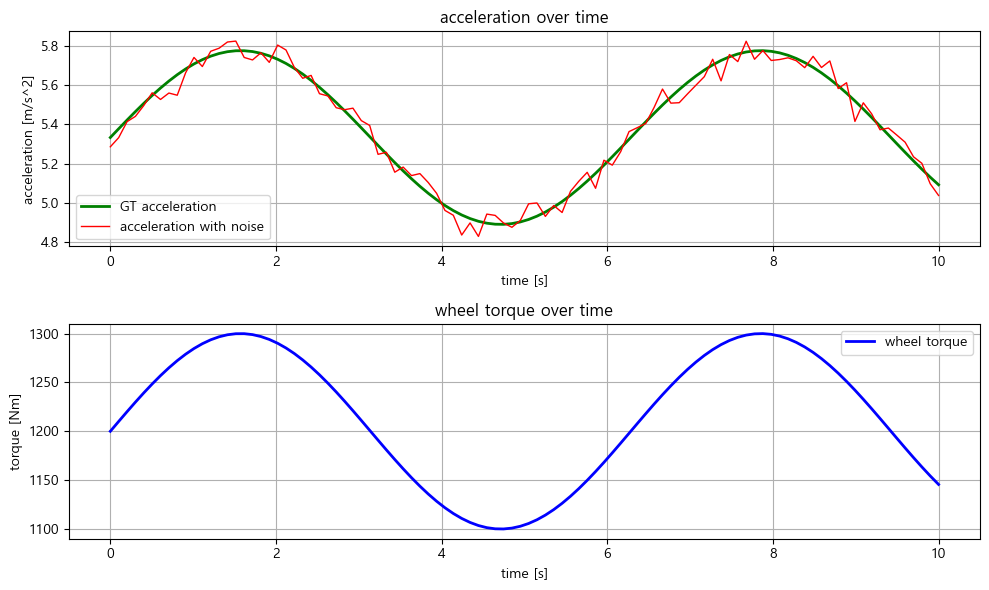

In [3]:
practice1 = loadmat(data_dir / "least_square_mat_file_practice1.mat")

time = practice1["time"].reshape(-1)
gt_accelerations_mps2 = practice1["gt_accelerations_mps2"].reshape(-1)
accelerations_with_noise_mps2 = practice1["accelerations_with_noise_mps2"].reshape(-1)
torques_Nm = practice1["torques_Nm"].reshape(-1)
wheel_radius_m = float(practice1["wheel_radius_m"])
gt_mass_kg = float(practice1["gt_mass_kg"])
sim_total_steps = len(time)

plt.figure()
plt.subplot(2, 1, 1)
plt.plot(time, gt_accelerations_mps2, "g-", linewidth=2)
plt.plot(time, accelerations_with_noise_mps2, "r-", linewidth=1)
plt.xlabel("time [s]")
plt.ylabel("acceleration [m/s^2]")
plt.legend(["GT acceleration", "acceleration with noise"])
plt.title("acceleration over time")

plt.subplot(2, 1, 2)
plt.plot(time, torques_Nm, "b-", linewidth=2)
plt.xlabel("time [s]")
plt.ylabel("torque [Nm]")
plt.legend(["wheel torque"])
plt.title("wheel torque over time")
plt.tight_layout()
plt.show()

### RLS 초기화 ($\hat{x}_0$, $P_0$)

미지수 $x = m$ 은 스칼라이므로 $n = 1$. 초기 추정 $\hat{x}_0 = 1000\,\mathrm{kg}$, 초기 공분산 $P_0 = 10^{10}$ 으로 **사전정보 거의 없음**을 표현한다.

In [4]:
num_of_state = 1            # mass_kg
num_of_measurement = 1      # 1/a

x_rls = np.zeros((num_of_state, sim_total_steps))
P_rls = [None] * sim_total_steps

x0 = np.array([[1000.0]], dtype=float)
P0 = np.array([[1e10]], dtype=float)

### 실습: RLS 갱신 루프 (TODO)

이론 절의 **코드 작성 원칙** 그대로 한 줄씩 풀어 쓴다. 각 스텝에서 다음을 채운다.

1. 측정 $y_k = 1/a_k$, 설계행렬 $H_k = r / (2\tau_k)$
2. 측정 잡음 분산 $R_k$ (여기선 동분산 $\sigma=0.05$ 고정)
3. $K_k$, $\hat{x}_k$, $P_k$ 갱신

In [8]:
isFirstStep = True

for idxSim in range(sim_total_steps):
    if isFirstStep:
        prev_x = x0
        prev_p = P0
        isFirstStep = False
    else:
        prev_x = x_rls[:, [idxSim - 1]]
        prev_p = P_rls[idxSim - 1]

    tau = torques_Nm[idxSim]
    a_meas = accelerations_with_noise_mps2[idxSim]

    # (1) 측정·설계행렬 모델링
    y_k = np.array([[1/a_meas]])  # TODO
    H_k = np.array([[wheel_radius_m/(2*tau)]])  # TODO
    R_k = np.array([[0.05**2]])  # TODO

    # (2) 칼만 이득 K_k  (innovation covariance S 부터 단계별로)

    # (3) 상태 갱신
    innovation = y_k - H_k @ prev_x  # TODO
    K = prev_p @ H_k.T @ np.linalg.inv(H_k @ prev_p @ H_k.T + R_k)
    x_rls[:, [idxSim]] = prev_x + K @ innovation  # TODO

    # (4) 공분산 갱신 (Joseph form)
    IKH = np.eye(1) - K @ H_k
    P_rls[idxSim] = IKH @ prev_p @ IKH.T + K @ R_k @ K.T  # TODO
    pass

### 추정 결과 (마지막 스텝)

In [9]:
estimated_mass = float(x_rls[0, -1])
print("Estimated mass: %.2f kg" % estimated_mass)
print("GT        mass: %.2f kg" % gt_mass_kg)
print("Abs error     : %.4f kg (%.3f %%)" % (
    abs(estimated_mass - gt_mass_kg),
    abs(estimated_mass - gt_mass_kg) / gt_mass_kg * 100.0,
))

Estimated mass: 1500.35 kg
GT        mass: 1500.00 kg
Abs error     : 0.3532 kg (0.024 %)


### 결과 시각화 — 수렴 과정과 공분산 감소

RLS 의 매력은 **수렴 과정 자체를 볼 수 있다**는 점이다. 시간에 따라 $\hat{m}_k$, 오차, $P_k$ 가 어떻게 줄어드는지 확인한다.

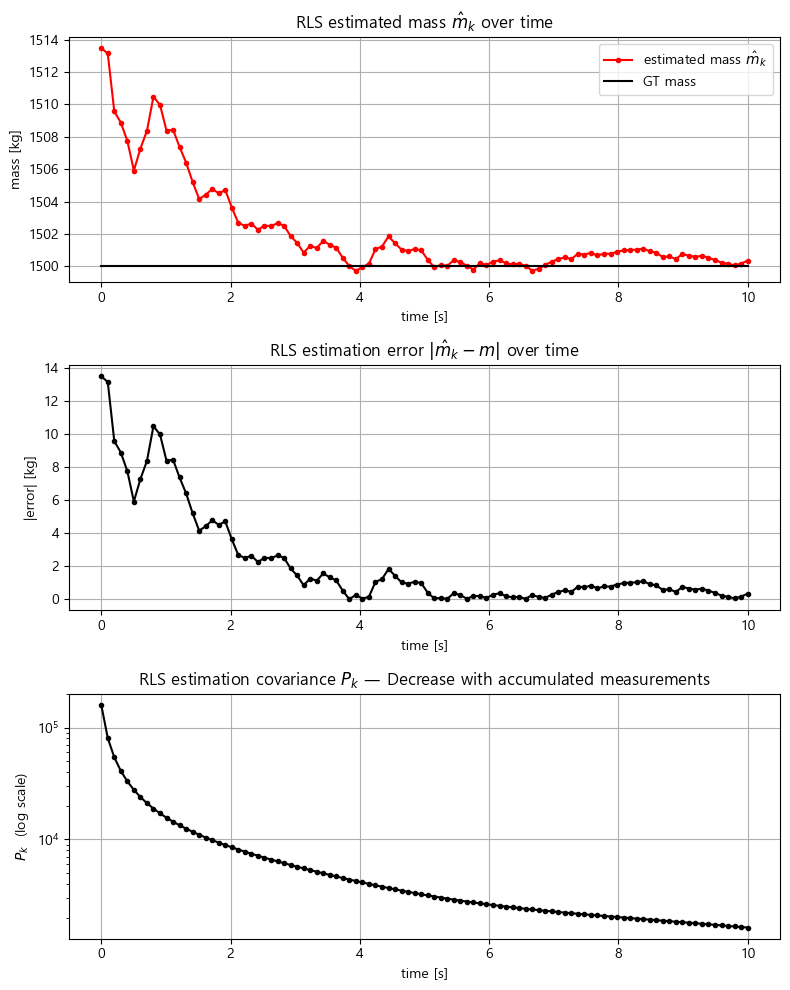

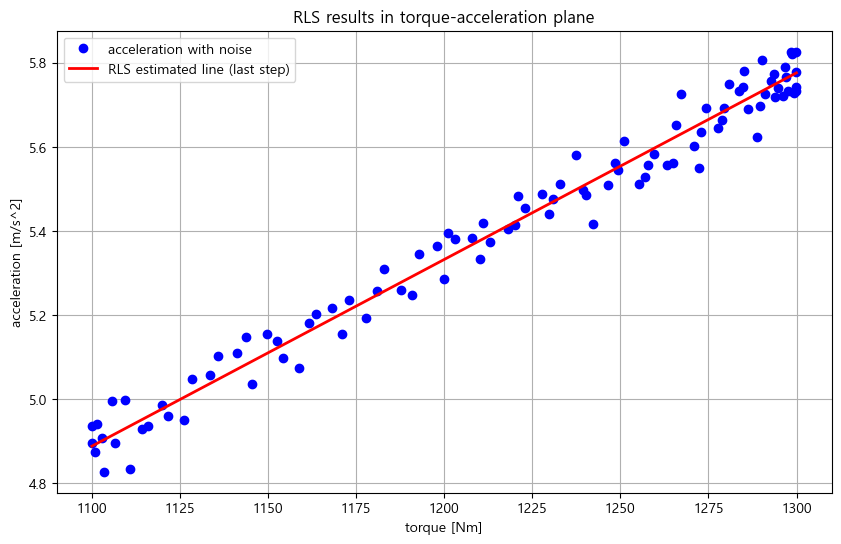

In [10]:
error_rls = np.abs(x_rls[0, :] - gt_mass_kg)
P_rls_diag = np.array([P[0, 0] for P in P_rls])

fig, axes = plt.subplots(3, 1, figsize=(8, 10))

axes[0].plot(time, x_rls[0, :], "r.-", label="estimated mass $\\hat{m}_k$")
axes[0].plot(time, gt_mass_kg * np.ones(sim_total_steps), "k", label="GT mass")
axes[0].set_xlabel("time [s]")
axes[0].set_ylabel("mass [kg]")
axes[0].set_title("RLS estimated mass $\\hat{m}_k$ over time")
axes[0].legend(loc="best")
axes[0].grid(True)

axes[1].plot(time, error_rls, "k.-")
axes[1].set_xlabel("time [s]")
axes[1].set_ylabel("|error| [kg]")
axes[1].set_title("RLS estimation error $|\\hat{m}_k - m|$ over time")
axes[1].grid(True)

axes[2].semilogy(time, P_rls_diag, "k.-")
axes[2].set_xlabel("time [s]")
axes[2].set_ylabel("$P_k$  (log scale)")
axes[2].set_title("RLS estimation covariance $P_k$ — Decrease with accumulated measurements")
axes[2].grid(True)

plt.tight_layout()
plt.show()

plt.figure()
plt.plot(torques_Nm, accelerations_with_noise_mps2, "bo", markerfacecolor="b", label="acceleration with noise")
torques_line = np.linspace(np.min(torques_Nm), np.max(torques_Nm), 100)
accelerations_line = (2 * torques_line / wheel_radius_m) / float(estimated_mass)
plt.plot(torques_line, accelerations_line, "r-", linewidth=2, label="RLS estimated line (last step)")
plt.xlabel("torque [Nm]")
plt.ylabel("acceleration [m/s^2]")
plt.title("RLS results in torque-acceleration plane")
plt.legend(loc="best")
plt.grid(True)
plt.show()

## Part B. 함께 따라하기: 낙하 물체의 초기 $(r_0, v_0, a_0)$ RLS 추정

- **목표**: 등가속도 모델 $r(t) = r_0 + v_0 t + \tfrac{1}{2} a_0 t^2$ 에서 거리 센서가 한 샘플씩 들어올 때 초기 상태를 RLS 로 추정한다.
- **데이터**: `least_square_mat_file_practice2.mat` (12장과 공유)

### 문제 설명

자유 낙하 물체의 고도를 거리 센서가 측정한다.

<img src="../resources/ch13/practice2_figure.png" width="700">

등가속 모델로부터
$$ r_{sensor}(t) = r_0 + v_0 t + \tfrac{1}{2} a_0 t^2 + v(t) $$
이고, 매 시각 $t_k$ 에서 한 줄짜리 설계행렬은
$$ H_k = \begin{bmatrix} 1 & t_k & t_k^2/2 \end{bmatrix}, \qquad x = \begin{bmatrix} r_0 \\ v_0 \\ a_0 \end{bmatrix} $$
이다. **Part A 와 같은 RLS 루프**에 $n=3$ 으로만 바꿔 넣는다.

**잡음 모델**: 본 센서는 거리 비례 잡음을 갖는다. 표준편차 $\sigma_k = 0.1 \times |y_k|$ 로 두어 $R_k = \sigma_k^2$ 로 스텝마다 다르게 잡는다 (12장 Part C 와 동일한 모델).

<img src="../resources/ch13/gaussian graph.png" width="500">

### GT / 센서 데이터 로드

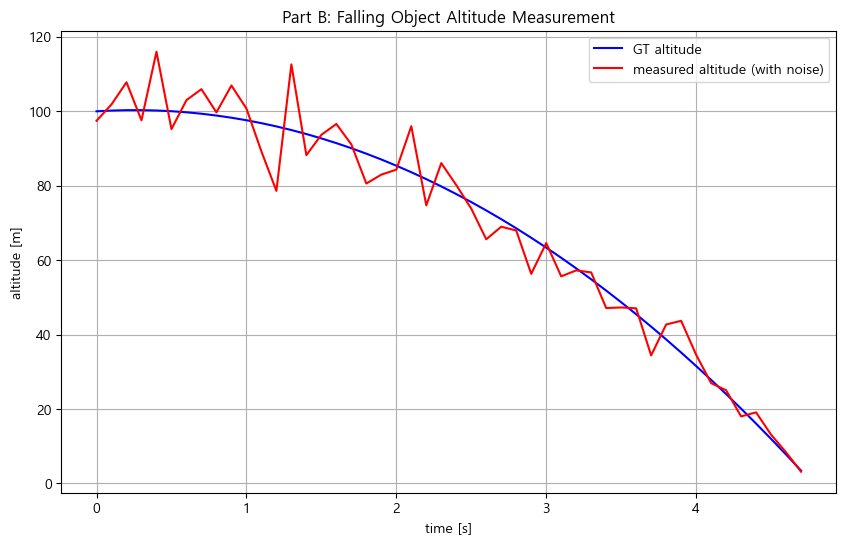

In [11]:
practice2 = loadmat(data_dir / "least_square_mat_file_practice2.mat")

sim_time = practice2["sim_time"].reshape(-1)
sim_total_steps_B = int(practice2["sim_total_steps"])
sim_altitude = practice2["sim_altitude"].reshape(-1)
sim_velocity = practice2["sim_velocity"].reshape(-1)
sim_acceleration = practice2["sim_acceleration"].reshape(-1)
sim_altitude_sensor = practice2["sim_altitude_sensor"].reshape(-1)
init_altitude = float(practice2["init_altitude"])
init_velocity = float(practice2["init_velocity"])
init_acceleration = float(practice2["init_acceleration"])

plt.figure()
plt.plot(sim_time, sim_altitude, "b", label="GT altitude")
plt.plot(sim_time, sim_altitude_sensor, "r", label="measured altitude (with noise)")
plt.xlabel("time [s]")
plt.ylabel("altitude [m]")
plt.title("Part B: Falling Object Altitude Measurement")
plt.legend(loc="best")
plt.grid(True)
plt.show()

### RLS 초기화 (3-state)

$P_0$ 는 대각에 $10^{10}$ 을 두어 세 미지수 모두 사전정보 거의 없음으로 둔다. $\hat{x}_0$ 는 $[0, 0, 0]^\top$.

In [12]:
num_of_state_B = 3   # [r0, v0, a0]

x_rls_B = np.zeros((num_of_state_B, sim_total_steps_B))
P_rls_B = [None] * sim_total_steps_B

x0_B = np.zeros((num_of_state_B, 1))
P0_B = np.eye(num_of_state_B) * 1e10

### 실습: 3-state RLS 루프 (TODO)

Part A 와 **구조는 동일**, 차원만 바뀐다. $H_k$ 행 벡터·$R_k$ 거리 비례 부분만 채우면 된다.

In [13]:
isFirstStep = True

for idxSim in range(sim_total_steps_B):
    if isFirstStep:
        prev_x = x0_B
        prev_p = P0_B
        isFirstStep = False
    else:
        prev_x = x_rls_B[:, [idxSim - 1]]
        prev_p = P_rls_B[idxSim - 1]

    t_k = sim_time[idxSim]
    y_meas = sim_altitude_sensor[idxSim]

    # (1) 측정·설계행렬·잡음 분산 모델링
    y_k = np.array([[y_meas]])  # TODO
    H_k = np.array([[1, t_k, 0.5 * t_k**2]])  # TODO
    R_k = (0.1 * np.abs(y_k))**2  # TODO

    # (2) 칼만 이득 K_k

    # (3) 상태 갱신
    innovation = y_k - H_k @ prev_x  # TODO
    K = prev_p @ H_k.T @ np.linalg.inv(H_k @ prev_p @ H_k.T + R_k)
    x_rls_B[:, [idxSim]] = prev_x + K @ innovation  # TODO

    # (4) 공분산 갱신 (Joseph form)
    IKH = np.eye(3) - K @ H_k
    P_rls_B[idxSim] = IKH @ prev_p @ IKH.T + K @ R_k @ K.T  # TODO
    pass

### 추정 결과 (마지막 스텝)

In [14]:
estimated_x_rls = x_rls_B[:, -1]
sim_true = np.array([init_altitude, init_velocity, init_acceleration])
abs_err = np.abs(estimated_x_rls - sim_true)

print("=== RLS 추정 결과 (Part B) ===")
print("Estimated  r0 = %.4f m,   v0 = %.4f m/s,   a0 = %.4f m/s^2" % tuple(estimated_x_rls))
print("GT         r0 = %.4f m,   v0 = %.4f m/s,   a0 = %.4f m/s^2" % tuple(sim_true))
print("|error|    r0 = %.4f m,   v0 = %.4f m/s,   a0 = %.4f m/s^2" % tuple(abs_err))

=== RLS 추정 결과 (Part B) ===
Estimated  r0 = 100.4483 m,   v0 = 1.5044 m/s,   a0 = -9.4296 m/s^2
GT         r0 = 100.0000 m,   v0 = 2.5000 m/s,   a0 = -9.8066 m/s^2
|error|    r0 = 0.4483 m,   v0 = 0.9956 m/s,   a0 = 0.3770 m/s^2


### 결과 시각화 — 세 상태별 수렴·오차·공분산

각 상태가 **언제부터** 안정되는지 보자. 보통 $r_0$ 가 가장 빨리 잡히고 $a_0$ 가 늦게 잡힌다(높은 차수 다항 계수가 식별이 어렵기 때문).

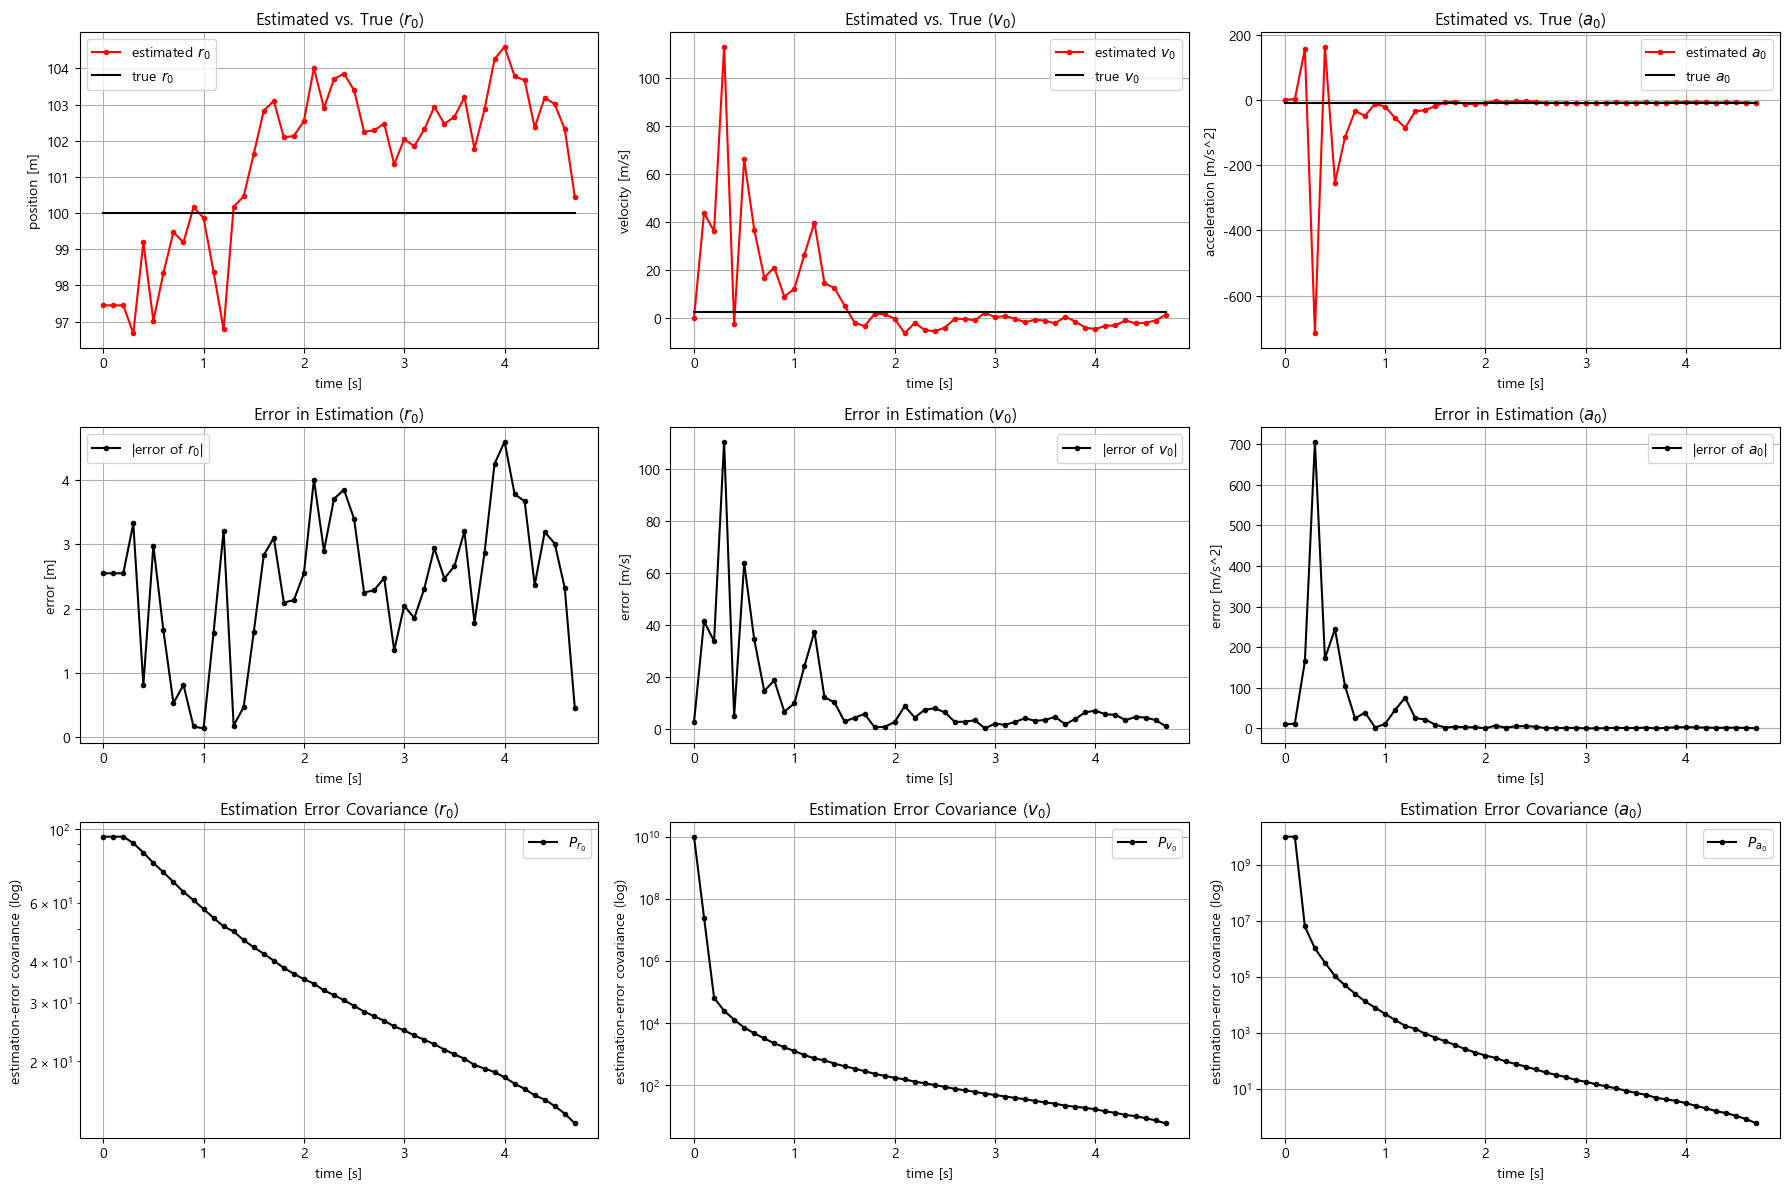

In [15]:
sim_true_col = sim_true[:, None]
error_rls_B = np.abs(x_rls_B - sim_true_col)

P_diag_B = np.zeros((3, sim_total_steps_B))
for k in range(sim_total_steps_B):
    P_diag_B[:, k] = np.diag(P_rls_B[k])

state_labels = [r"$r_0$", r"$v_0$", r"$a_0$"]
state_units = ["position [m]", "velocity [m/s]", "acceleration [m/s^2]"]
error_units = ["error [m]", "error [m/s]", "error [m/s^2]"]
cov_labels = [r"$P_{r_0}$", r"$P_{v_0}$", r"$P_{a_0}$"]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))

for i in range(3):
    ax = axes[0, i]
    ax.plot(sim_time, x_rls_B[i, :], "r.-", label=f"estimated {state_labels[i]}")
    ax.plot(sim_time, sim_true[i] * np.ones(sim_total_steps_B), "k", label=f"true {state_labels[i]}")
    ax.set_xlabel("time [s]")
    ax.set_ylabel(state_units[i])
    ax.set_title(f"Estimated vs. True ({state_labels[i]})")
    ax.legend(loc="best")
    ax.grid(True)

    ax = axes[1, i]
    ax.plot(sim_time, error_rls_B[i, :], "k.-", label=f"|error of {state_labels[i]}|")
    ax.set_xlabel("time [s]")
    ax.set_ylabel(error_units[i])
    ax.set_title(f"Error in Estimation ({state_labels[i]})")
    ax.legend(loc="best")
    ax.grid(True)

    ax = axes[2, i]
    ax.semilogy(sim_time, P_diag_B[i, :], "k.-", label=cov_labels[i])
    ax.set_xlabel("time [s]")
    ax.set_ylabel("estimation-error covariance (log)")
    ax.set_title(f"Estimation Error Covariance ({state_labels[i]})")
    ax.legend(loc="best")
    ax.grid(True)

plt.tight_layout()
plt.show()

## Part C. 스스로 해보기: 거리 센서 1차 보정(게인·오프셋)을 RLS 로

Part A~B 에서 익힌 RLS 루프를 직접 적용해 본다. **12장 Part D 와 동일한 시나리오**(거리 센서 게인·오프셋 보정)이지만, 여기서는 **배치 LS 가 아닌 RLS** 로 푼다.

- **목표**: 실제 거리 $d_i$ 에 대해 센서가 $y_i = g\, d_i + b + v_i$ 형태로 읽힌다고 가정하고, 데이터를 **한 샘플씩** 받으며 **게인 $g$** 와 **오프셋 $b$** 를 재귀적으로 추정한다.
- **데이터**: 아래 셀에서 **합성 데이터**를 생성한다 (별도 `.mat` 파일 없음).
- **자체 검증**: 마지막 스텝의 $\hat{g}_N$, $\hat{b}_N$ 은 **12장 Part D 의 배치 LS 결과와 거의 일치**해야 한다.

### 문제 설명

차량/로봇에 장착된 거리 센서를 오프라인 보정한다. 실험장에서 레이저 기준 거리 $d_i$ [m] 를 바꿔 가며 센서 출력 $y_i$ [m] 를 $N$ 회 수집한다.

센서 모델 (1차 보정):
$$ y_i = g\, d_i + b + v_i, \qquad v_i \sim \mathcal{N}(0, \sigma^2),\ \ \sigma = 0.4\,\mathrm{m} $$

**진짜 값(GT)**: $g_{\mathrm{GT}} = 1.05$, $b_{\mathrm{GT}} = 0.30$ m  
**미지 벡터**: $x = [g,\ b]^\top$, 스텝별 설계행렬: $H_k = [d_k,\ 1]$

**학습 과제**

1. $d_i \in [5, 50]$ m 구간에서 $N = 40$ 개의 기준 거리를 잡고, 위 모델로 $y_i$ 를 생성한다 (시드 고정).
2. RLS 루프를 직접 작성한다 — Part A·B 의 구조 그대로, $n = 2$.
3. 매 스텝의 $\hat{g}_k$, $\hat{b}_k$ 시계열을 추출해 **수렴 과정**을 그린다.
4. 마지막 스텝 $\hat{g}_N$, $\hat{b}_N$ 과 GT 의 오차를 출력한다.
5. *(자체 검증)* 12장 Part D 의 배치 LS 결과와 수치가 일치하는지 비교한다 (시드·잡음 동일 가정).

**완료 기준**

- $\hat{g}_N$, $\hat{b}_N$ 이 GT 와 **오차 5% 이내** (시드 고정 시 달성 가능)
- 시각화에서 $P_k$ 두 대각 항목이 시간 따라 **감소**해야 함

**힌트**

- 초기화: $\hat{x}_0 = [0, 0]^\top$, $P_0 = 10^{10}\, I_2$
- $H_k$ 는 `(1, 2)` 행 벡터, `np.array([[d_k, 1.0]])`
- $R_k$ 는 동분산 → `np.array([[SIGMA_V ** 2]])`
- 그 외 갱신식은 Part A·B 와 완전히 동일

### 실습

위 문제·힌트만 보고 먼저 직접 구현해 본다. (아래 셀이 비어 있다.)

In [ ]:
# 권장 단계:
#   1) np.random.seed(42), 합성 데이터 생성 (d_true, y_meas)
#   2) RLS 초기화 (x0, P0, x_rls_C, P_rls_C 등)
#   3) for 루프: y_k, H_k, R_k → K → x_k, P_k
#   4) print: g_hat, b_hat, GT 와의 상대 오차
#   5) 시각화: g_hat_k / b_hat_k / P_k 수렴 곡선

np.random.seed(42)
G_GT = 1.05
B_GT = 0.30
SIGMA_V = 0.4
N_SAMPLES = 40

d_true = np.linspace(5.0, 50.0, N_SAMPLES)

y_meas = G_GT * d_true + B_GT + SIGMA_V * np.random.randn(N_SAMPLES)



### 스카폴딩 (막힐 때 참고)

아래 셀은 변수 골격·시각화 코드만 깔아둔 **스카폴딩** 이다. 핵심 RLS 식은 모두 `# TODO` 로 비워 두었다.  
위 빈 셀에서 막혔다면 이 셀의 `# TODO` 를 한 줄씩 채우는 방식으로 풀어 본다. `np.random.seed(42)` 는 **변경하지 않는다**.

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


=== Part C RLS ===
Estimated  g = 1.0429,  b = 0.4071 m   (마지막 스텝)
GT         g = 1.0500,  b = 0.3000 m
Rel. error g = 0.67 %
Abs. error b = 0.1071 m

[자체 검증] 같은 데이터에 대한 배치 LS 해:
  Batch LS  g = 1.042924,  b = 0.407139 m
  RLS 마지막 스텝과의 차이: dg = 1.11e-08, db = 3.96e-07


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


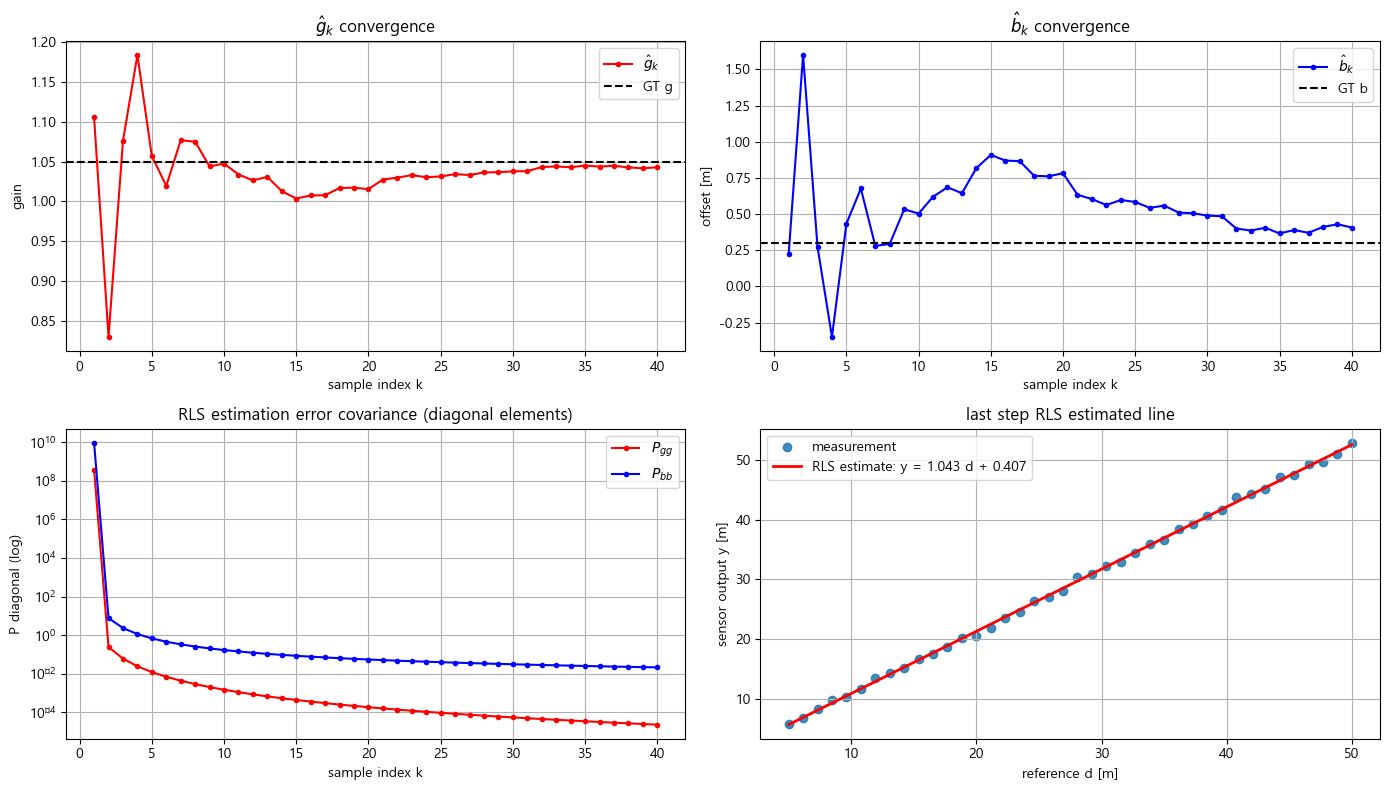

In [16]:
# Part C: distance sensor calibration with RLS (TODO)

np.random.seed(42)

G_GT = 1.05
B_GT = 0.30           # [m]
SIGMA_V = 0.4         # [m], i.i.d. measurement noise
N_SAMPLES = 40

d_true = np.linspace(5.0, 50.0, N_SAMPLES)

# TODO (1): y_meas 합성
y_meas = G_GT * d_true + B_GT + SIGMA_V * np.random.randn(N_SAMPLES)

num_of_state_C = 2
x_rls_C = np.zeros((num_of_state_C, N_SAMPLES))
P_rls_C = [None] * N_SAMPLES

# TODO (2): 초기 추정·공분산
x0_C = np.zeros((num_of_state_C, 1))
P0_C = np.eye(num_of_state_C) * 1e10

isFirstStep = True
for k in range(N_SAMPLES):
    if isFirstStep:
        prev_x = x0_C
        prev_p = P0_C
        isFirstStep = False
    else:
        prev_x = x_rls_C[:, [k - 1]]
        prev_p = P_rls_C[k - 1]

    # TODO (3): y_k, H_k, R_k
    y_k = np.array([[y_meas[k]]])  # TODO
    H_k = np.array([[d_true[k], 1.0]])  # TODO
    R_k = np.array([[SIGMA_V**2]])  # TODO

    # TODO (4): K_k 계산 (Part A·B 와 동일)
    K_k = prev_p @ H_k.T @ np.linalg.inv(H_k @ prev_p @ H_k.T + R_k)

    # TODO (5): 상태·공분산 갱신
    innovation = y_k - H_k @ prev_x  # TODO
    x_rls_C[:, [k]] = prev_x + K_k @ innovation  # TODO
    IKH = np.eye(2) - K_k @ H_k
    P_rls_C[k] = IKH @ prev_p @ IKH.T + K_k @ R_k @ K_k.T  # TODO
    pass

# 마지막 스텝의 추정치 출력 — 위 TODO 를 다 채우면 정상 출력된다
g_hat = float(x_rls_C[0, -1])
b_hat = float(x_rls_C[1, -1])

print("=== Part C RLS ===")
print(f"Estimated  g = {g_hat:.4f},  b = {b_hat:.4f} m   (마지막 스텝)")
print(f"GT         g = {G_GT:.4f},  b = {B_GT:.4f} m")
print(f"Rel. error g = {abs(g_hat - G_GT) / G_GT * 100:.2f} %")
print(f"Abs. error b = {abs(b_hat - B_GT):.4f} m")

# (자체 검증) 같은 데이터에 대한 배치 LS 결과와 비교
H_batch = np.column_stack([d_true, np.ones_like(d_true)])
Y_batch = y_meas.reshape(-1, 1)
x_hat_ls = np.linalg.inv(H_batch.T @ H_batch) @ H_batch.T @ Y_batch
print("\n[자체 검증] 같은 데이터에 대한 배치 LS 해:")
print(f"  Batch LS  g = {float(x_hat_ls[0, 0]):.6f},  b = {float(x_hat_ls[1, 0]):.6f} m")
print(f"  RLS 마지막 스텝과의 차이: dg = {abs(g_hat - float(x_hat_ls[0, 0])):.2e}, db = {abs(b_hat - float(x_hat_ls[1, 0])):.2e}")

# 시각화: 수렴 과정
P_diag_C = np.zeros((2, N_SAMPLES))
for k in range(N_SAMPLES):
    P_diag_C[:, k] = np.diag(P_rls_C[k])

step_axis = np.arange(1, N_SAMPLES + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(step_axis, x_rls_C[0, :], "r.-", label=r"$\hat{g}_k$")
axes[0, 0].axhline(G_GT, color="k", linestyle="--", label="GT g")
axes[0, 0].set_xlabel("sample index k")
axes[0, 0].set_ylabel("gain")
axes[0, 0].set_title(r"$\hat{g}_k$ convergence")
axes[0, 0].legend(loc="best")
axes[0, 0].grid(True)

axes[0, 1].plot(step_axis, x_rls_C[1, :], "b.-", label=r"$\hat{b}_k$")
axes[0, 1].axhline(B_GT, color="k", linestyle="--", label="GT b")
axes[0, 1].set_xlabel("sample index k")
axes[0, 1].set_ylabel("offset [m]")
axes[0, 1].set_title(r"$\hat{b}_k$ convergence")
axes[0, 1].legend(loc="best")
axes[0, 1].grid(True)

axes[1, 0].semilogy(step_axis, P_diag_C[0, :], "r.-", label=r"$P_{gg}$")
axes[1, 0].semilogy(step_axis, P_diag_C[1, :], "b.-", label=r"$P_{bb}$")
axes[1, 0].set_xlabel("sample index k")
axes[1, 0].set_ylabel("P diagonal (log)")
axes[1, 0].set_title("RLS estimation error covariance (diagonal elements)")
axes[1, 0].legend(loc="best")
axes[1, 0].grid(True)

axes[1, 1].scatter(d_true, y_meas, label="measurement", color="tab:blue", alpha=0.85)
d_line = np.linspace(d_true.min(), d_true.max(), 100)
y_line = g_hat * d_line + b_hat
axes[1, 1].plot(d_line, y_line, "r-", linewidth=2, label=f"RLS estimate: y = {g_hat:.3f} d + {b_hat:.3f}")
axes[1, 1].set_xlabel("reference d [m]")
axes[1, 1].set_ylabel("sensor output y [m]")
axes[1, 1].set_title("last step RLS estimated line")
axes[1, 1].legend(loc="best")
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

## 정리

- **Part A**: 스칼라 미지수($m$)에 대한 RLS — 12장 Part A 의 배치 LS 와 같은 답이 한 샘플씩 누적되며 나오는 것을 확인했다.
- **Part B**: 3-state RLS — $r_0, v_0, a_0$ 가 서로 다른 속도로 수렴한다 ($r_0 \gg v_0 \gg a_0$ 순). 거리 비례 잡음 $R_k$ 가 자연스럽게 들어간다.
- **Part C**: 게인·오프셋 보정을 RLS 로 풀었고, 배치 LS 와 마지막 스텝에서 동치임을 수치로 확인했다.

**다음 단계**: `14_Propagation.ipynb` — 미지수 $x$ 가 **시간에 따라 변하는** 경우 (동적 시스템) 로 확장하면 칼만 필터(KF)가 된다. RLS 는 KF 의 *상태가 상수*인 특수한 경우라고 볼 수 있다.